In [4]:
%pip install category_encoders

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Data_set/train.csv')

df['date'] = pd.to_datetime(df['date'])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [7]:
df.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [8]:
df['date'] = pd.to_datetime(df['date'])
df['date'].min(), df['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

<Axes: xlabel='date'>

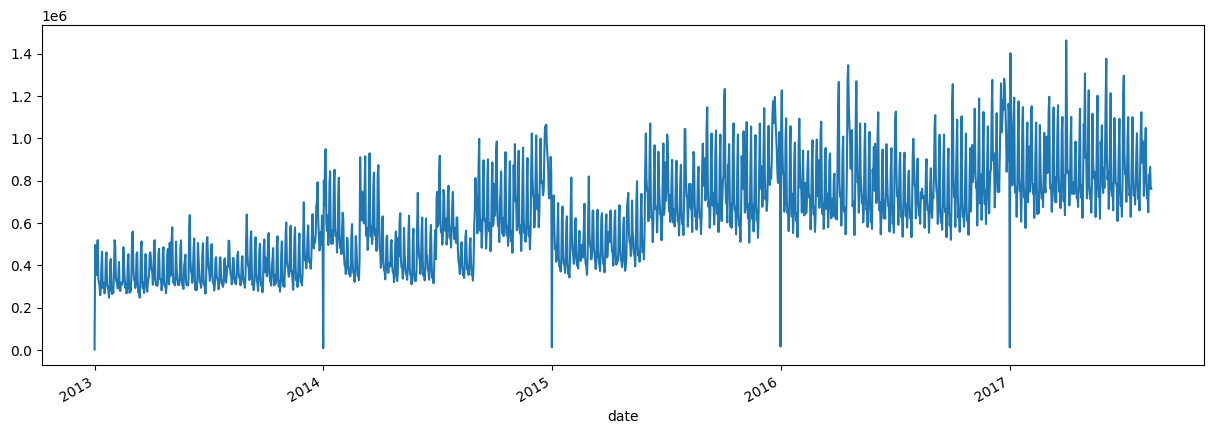

In [9]:
df.groupby('date')['sales'].sum().plot(figsize=(15,5))

In [10]:
df['month'] = df['date'].dt.month
df['dayofweek']= df['date'].dt.dayofweek

<Axes: xlabel='month'>

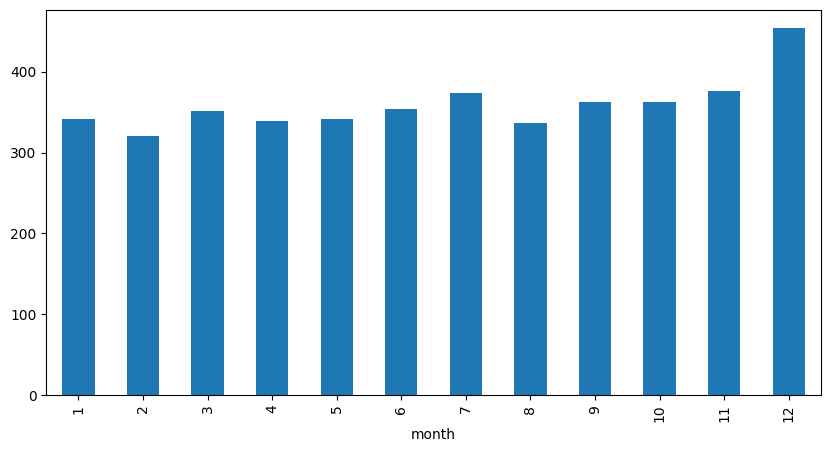

In [11]:
df.groupby('month')['sales'].mean().plot(kind='bar', figsize=(10,5))

<Axes: xlabel='dayofweek'>

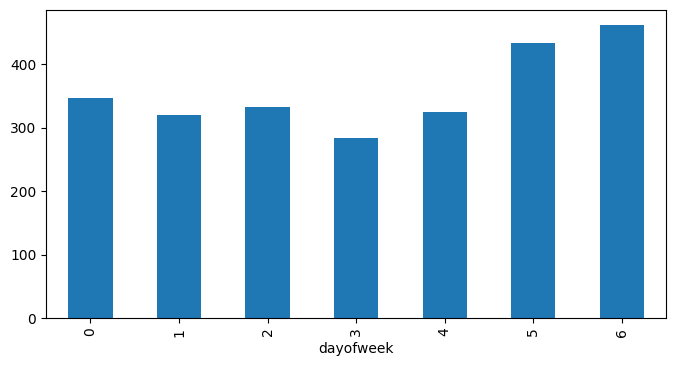

In [12]:
df.groupby('dayofweek')['sales'].mean().plot(kind='bar', figsize=(8,4))

In [13]:
df['lag1']  = df.groupby(['store_nbr','family'])['sales'].shift(1)
df['lag7']  = df.groupby(['store_nbr','family'])['sales'].shift(7)
df['lag30'] = df.groupby(['store_nbr','family'])['sales'].shift(30)


In [25]:
df = df[df['store_nbr'] == 1]

In [14]:
df['rolling_7'] = df.groupby(['store_nbr', 'family'])['sales'].shift(1).rolling(7).mean()
df['rolling_30'] = df.groupby(['store_nbr','family'])['sales'].shift(1).rolling(30).mean()

In [15]:
print(df[['lag1','lag7','lag30','rolling_7','rolling_30']].head())

   lag1  lag7  lag30  rolling_7  rolling_30
0   NaN   NaN    NaN        NaN         NaN
1   NaN   NaN    NaN        NaN         NaN
2   NaN   NaN    NaN        NaN         NaN
3   NaN   NaN    NaN        NaN         NaN
4   NaN   NaN    NaN        NaN         NaN


In [16]:
df = df.dropna(subset=['lag1','lag7','lag30','rolling_7','rolling_30'])

In [17]:
train = df[df['date']<'2013-01-01']
test = df[df['date']>='2013-01-01']

In [18]:
y_pred_naive = test['lag1'].values

In [19]:
features = ['onpromotion','lag1','lag7','lag30','rolling_7','rolling_30']

X_train = train[features]
y_train = train['sales']

X_test  = test[features]
y_test  = test['sales']

In [30]:
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')

MAE: 63.78
MSE: 78032.55


In [20]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, val_index in tscv.split(df):
    train_data = df.iloc[train_index]
    val_data = df.iloc[val_index]

X_train = train_data[features]
y_train = train_data['sales']

X_val = val_data[features]
y_val = val_data['sales']


X_test = test[features]
y_test = test['sales']

In [22]:
xgb = XGBRegressor(
 n_estimators=1000,
 learning_rate=0.05,
 max_depth=6,
 subsample=0.8,
 colsample_bytree=0.8,
 random_state=42,
 n_jobs=-1,
 eval_metric ='rmse'
)

xgb.fit(X_train, y_train,

eval_set=[(X_val, y_val)],
)

y_pred_xgb = xgb.predict(X_test)

[0]	validation_0-rmse:1325.92792
[1]	validation_0-rmse:1266.15347
[2]	validation_0-rmse:1209.75013
[3]	validation_0-rmse:1157.63368
[4]	validation_0-rmse:1107.74155
[5]	validation_0-rmse:1059.50250
[6]	validation_0-rmse:1014.67753
[7]	validation_0-rmse:972.34136
[8]	validation_0-rmse:932.87504
[9]	validation_0-rmse:895.53165
[10]	validation_0-rmse:860.08462
[11]	validation_0-rmse:825.81328
[12]	validation_0-rmse:793.37102
[13]	validation_0-rmse:763.77160
[14]	validation_0-rmse:736.78654
[15]	validation_0-rmse:710.71616
[16]	validation_0-rmse:686.04079
[17]	validation_0-rmse:664.31305
[18]	validation_0-rmse:642.55179
[19]	validation_0-rmse:622.62606
[20]	validation_0-rmse:603.49467
[21]	validation_0-rmse:586.01999
[22]	validation_0-rmse:569.80682
[23]	validation_0-rmse:554.40850
[24]	validation_0-rmse:540.33210
[25]	validation_0-rmse:527.34342
[26]	validation_0-rmse:514.41237
[27]	validation_0-rmse:503.17497
[28]	validation_0-rmse:493.20952
[29]	validation_0-rmse:483.18639
[30]	validati

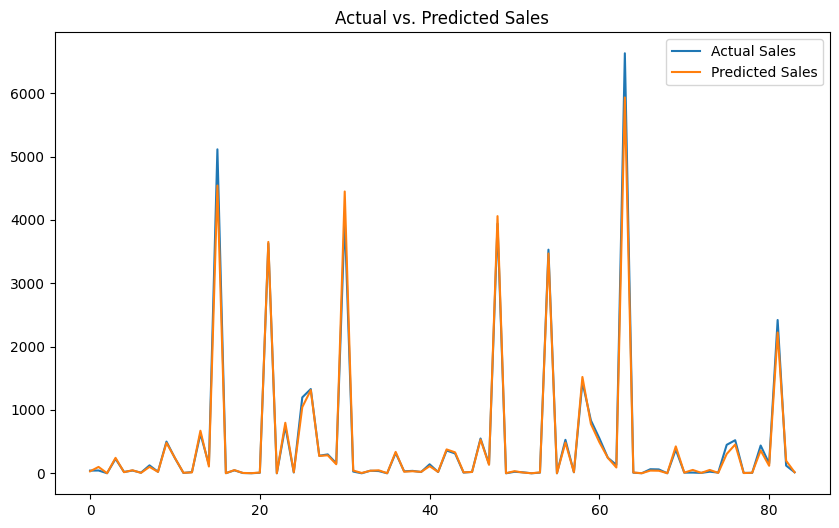

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values [-84:], label='Actual Sales')
plt.plot(y_pred_xgb [-84:], label='Predicted Sales')
plt.legend()
plt.title('Actual vs. Predicted Sales')
plt.show()